## Chl file for shortwave penentration crashes with a Nan error in ice shelf config on initialisation

Chl file was made for the panan with no ice shelves, but the metadata suggests masks/topography info was not used in creating the file

```
history = "Created by ds0092 (dougiesquire) on 2026-05-20, using https://github.com/ACCESS-NRI/om3-scripts/blob/7b4ae0dae754f25153da5651501a0359b1199d41//wombat_ic_generation/regrid_forcing.py: python3 regrid_forcing.py --forcing-filename=/g/data/ik11/inputs/GlobColour/2026.05.07/cmems_obs-oc_glo_bgc-plankton_my_l4-multi-4km-climatology-filled_P1M.nc --hgrid-filename=/g/data/vk83/prerelease/configurations/inputs/access-om3/panan.4km/2026.01.08/ocean_hgrid.nc --output-filename=/g/data/tm70/ds0092/model/inputs/chlorophyll/panan.4km/2026.05.20/chl_globcolour_monthly_clim.nc"
```

Plot and compare to mask to find spot that went wrong. Try to set it to zero.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from dask.distributed import Client


In [2]:
client = Client(threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46881,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33361,Total threads: 1
Dashboard: /proxy/34431/status,Memory: 8.97 GiB
Nanny: tcp://127.0.0.1:45785,


In [18]:
topog = xr.open_mfdataset('/g/data/vk83/prerelease/configurations/inputs/access-om3/panan-isf.4km/2026.01.08/topog.nc')
chl = xr.open_mfdataset('/g/data/vk83/prerelease/configurations/inputs/access-om3/panan.4km/2026.05.20/chl_globcolour_monthly_clim.nc')


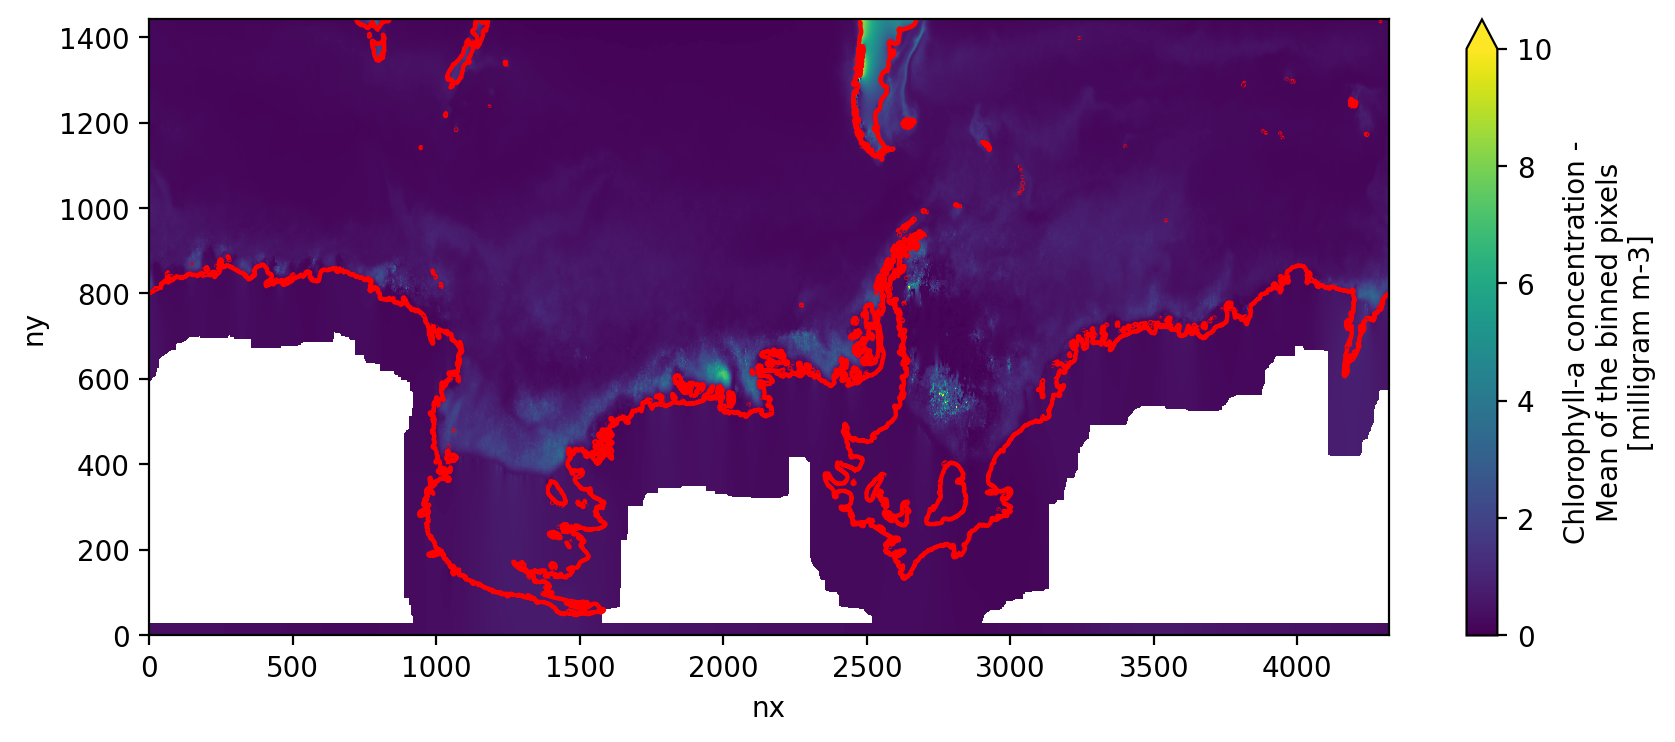

In [19]:
fig,axes = plt.subplots(dpi = 200, figsize = (10,4))
chl.CHL.isel(time = 0).plot(vmax = 10)
topog.depth.plot.contour(levels = [0.1],colors = 'r')

Zoom into Ross

(0.0, 200.0)

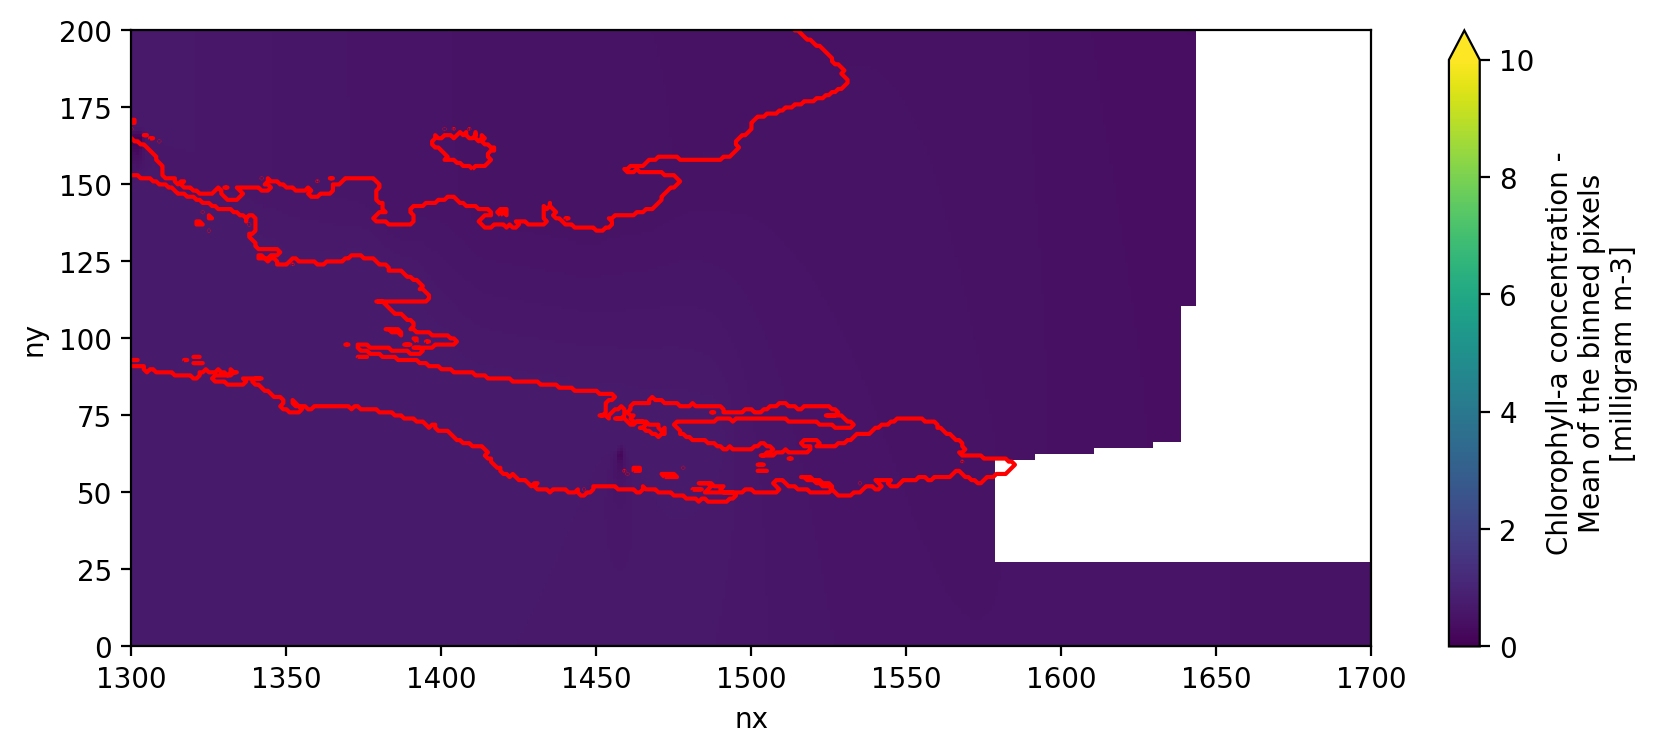

In [20]:
fig,axes = plt.subplots(dpi = 200, figsize = (10,4))
chl.CHL.isel(time = 0).plot(vmax = 10)
topog.depth.plot.contour(levels = [0.1],colors = 'r')
plt.xlim(1300,1700)
plt.ylim(0,200)

This was the error so the location matches:
```
FATAL from PE     9: MOM_diabatic_aux set_pen_shortwave:  Time_interp negative chl of  -1.0000E+10 at i,j = 36, 5 lon/lat =  -1.4838E+02 E  -8.5196E+01 N.

FATAL from PE     3: MOM_diabatic_aux set_pen_shortwave:  Time_interp negative chl of  -1.0000E+10 at i,j = 36, 32 lon/lat =  -1.4838E+02 E  -8.5260E+01 N.


In [21]:
chl

<xarray.Dataset> Size: 399MB
Dimensions:             (time: 12, ny: 1442, nx: 4320, nv: 2)
Coordinates:
  * time                (time) datetime64[ns] 96B 2011-01-16T12:00:00 ... 201...
  * ny                  (ny) float32 6kB 0.0 1.0 2.0 ... 1.44e+03 1.441e+03
  * nx                  (nx) float32 17kB 0.0 1.0 2.0 ... 4.318e+03 4.319e+03
    lon                 (ny, nx) float64 50MB dask.array<chunksize=(1442, 4320), meta=np.ndarray>
    lat                 (ny, nx) float64 50MB dask.array<chunksize=(1442, 4320), meta=np.ndarray>
    climatology_bounds  (time, nv) datetime64[ns] 192B dask.array<chunksize=(1, 2), meta=np.ndarray>
Dimensions without coordinates: nv
Data variables:
    CHL                 (time, ny, nx) float32 299MB dask.array<chunksize=(1, 721, 2160), meta=np.ndarray>
Attributes: (12/93)
    lon_step:                        0.041666668
    keywords:                        EARTH SCIENCE > OCEANS > OCEAN CHEMISTRY...
    cmems_product_id:                OCEANCOLOUR_GLO_BGC_L4_MY_009_104
    lat_step:                        0.041666668
    grid_mapping:                    Equirectangular
    title:                           Global ocean surface Chlorophyll-a conce...
    ...                              ...
    geospatial_vertical_positive:    up
    date_created:                    2023-10-18T13:28:38Z
    nb_valid_bins:                   14436766
    pct_valid_bins:                  38.678749785665296
    regrid_method:                   bilinear
    inputFile:                       /g/data/ik11/inputs/GlobColour/2026.05.0...

In [22]:
chl.attrs['history']

'Created by ds0092 (dougiesquire) on 2026-05-20, using https://github.com/ACCESS-NRI/om3-scripts/blob/7b4ae0dae754f25153da5651501a0359b1199d41//wombat_ic_generation/regrid_forcing.py: python3 regrid_forcing.py --forcing-filename=/g/data/ik11/inputs/GlobColour/2026.05.07/cmems_obs-oc_glo_bgc-plankton_my_l4-multi-4km-climatology-filled_P1M.nc --hgrid-filename=/g/data/vk83/prerelease/configurations/inputs/access-om3/panan.4km/2026.01.08/ocean_hgrid.nc --output-filename=/g/data/tm70/ds0092/model/inputs/chlorophyll/panan.4km/2026.05.20/chl_globcolour_monthly_clim.nc'

In [23]:
# set nans to zero

chl['CHL'] = chl.CHL.fillna(0)

(0.0, 200.0)

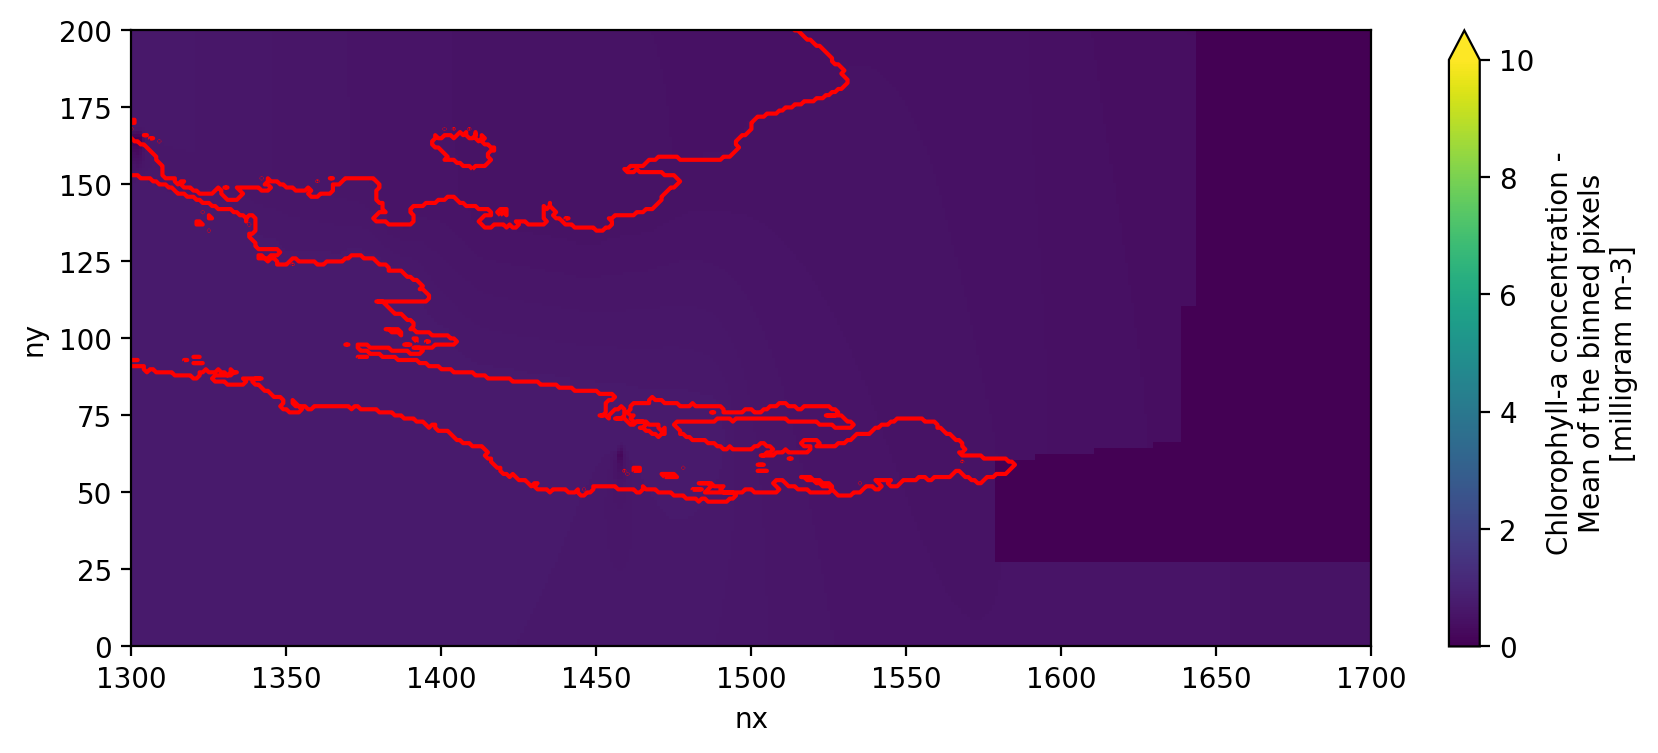

In [24]:
fig,axes = plt.subplots(dpi = 200, figsize = (10,4))
chl.CHL.isel(time = 0).plot(vmax = 10)
topog.depth.plot.contour(levels = [0.1],colors = 'r')
plt.xlim(1300,1700)
plt.ylim(0,200)

In [25]:
chl.attrs['history'] = chl.attrs['history'] + 'CLAIRE Set nans to zero using https://github.com/claireyung/mom6-panAn-iceshelf-tools/tree/main/initial-conditions/claire/quick-chl-file-set-nans.ipynb'

In [26]:
chl

<xarray.Dataset> Size: 399MB
Dimensions:             (time: 12, ny: 1442, nx: 4320, nv: 2)
Coordinates:
  * time                (time) datetime64[ns] 96B 2011-01-16T12:00:00 ... 201...
  * ny                  (ny) float32 6kB 0.0 1.0 2.0 ... 1.44e+03 1.441e+03
  * nx                  (nx) float32 17kB 0.0 1.0 2.0 ... 4.318e+03 4.319e+03
    lon                 (ny, nx) float64 50MB dask.array<chunksize=(1442, 4320), meta=np.ndarray>
    lat                 (ny, nx) float64 50MB dask.array<chunksize=(1442, 4320), meta=np.ndarray>
    climatology_bounds  (time, nv) datetime64[ns] 192B dask.array<chunksize=(1, 2), meta=np.ndarray>
Dimensions without coordinates: nv
Data variables:
    CHL                 (time, ny, nx) float32 299MB dask.array<chunksize=(1, 721, 2160), meta=np.ndarray>
Attributes: (12/93)
    lon_step:                        0.041666668
    keywords:                        EARTH SCIENCE > OCEANS > OCEAN CHEMISTRY...
    cmems_product_id:                OCEANCOLOUR_GLO_BGC_L4_MY_009_104
    lat_step:                        0.041666668
    grid_mapping:                    Equirectangular
    title:                           Global ocean surface Chlorophyll-a conce...
    ...                              ...
    geospatial_vertical_positive:    up
    date_created:                    2023-10-18T13:28:38Z
    nb_valid_bins:                   14436766
    pct_valid_bins:                  38.678749785665296
    regrid_method:                   bilinear
    inputFile:                       /g/data/ik11/inputs/GlobColour/2026.05.0...

In [27]:
chl.to_netcdf('/g/data/x77/cy8964/mom6/input/input-8km/chl_globcolour_monthly_clim.nc',unlimited_dims="time")